C:\Users\Admin\AppData\Local\Temp\ipykernel_8500\3490737415.py:7: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Admin\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Admin\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Admin\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please d


image 1/1 D:\workplace\pythonleng\x\license-plate-ocr\SourceCode\training\..\samples\img_2.png: 736x960 4 plates, 283.9ms
Speed: 6.1ms preprocess, 283.9ms inference, 1.9ms postprocess per image at shape (1, 3, 736, 960)
(576, 768, 3)


C:\Users\Admin\AppData\Local\Temp\ipykernel_8500\3490737415.py:28: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(crop)


[{'input_path': None, 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[ 29, ...,  32],
        ...,
        [  0, ...,   0]],

       ...,

       [[ 63, ...,  81],
        ...,
        [117, ..., 102]]], shape=(129, 138, 3), dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 0, 'rot_img': array([[[ 29, ...,  32],
        ...,
        [  0, ...,   0]],

       ...,

       [[ 63, ...,  81],
        ...,
        [117, ..., 102]]], shape=(129, 138, 3), dtype=uint8), 'output_img': array([[[ 22, ...,  34],
        ...,
        [144, ..., 122]],

       ...,

       [[164, ..., 182],
        ...,
        [ 99, ...,  82]]], shape=(129, 138, 3), dtype=uint8)}, 'dt_polys': [array([[15, 29],
       ...,
       [16, 73]], shape=(4, 2), dtype=int16), array([[  9,  68],
       ...,
       [  9, 115]], shape=(4, 2), dtype=int16)], 'model_settings': {'use_doc_preprocessor': True, 'use_t

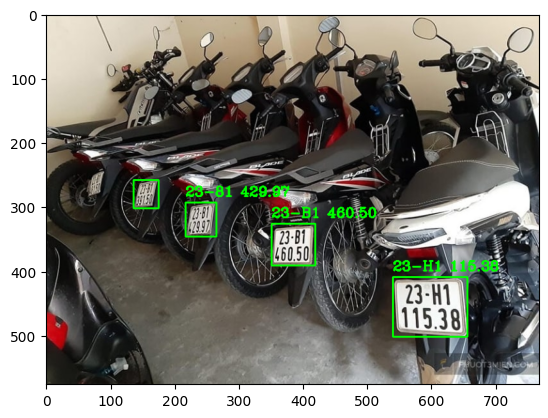

In [3]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
import cv2

model = YOLO("../model/best_pl_detection.pt")
ocr = PaddleOCR(use_angle_cls=True, lang='en')
predict = model("../samples/img_2.png")
img = cv2.imread("../samples/img_2.png")
print(img.shape)
for r in predict:

    boxes = r.boxes.xyxy

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        offset_w = int((x2 - x1) * 0.1)
        offset_h = int((y2 - y1) * 0.2)
        x1_crop = max(0, x1 - offset_w)
        y1_crop = max(0, y1 - offset_h)
        x2_crop = min(img.shape[1], x2 + offset_w)
        y2_crop = min(img.shape[0], y2 + offset_h)

        crop = img[y1_crop:y2_crop, x1_crop:x2_crop]

        result = ocr.ocr(crop)
        plate = ""
        if result:
            texts = result[0]['rec_texts']
            scores = result[0]['rec_scores']
            plate = " ".join(texts)
        if len(scores) > 0:
            conf = sum(scores)/len(scores)

        if conf > 0:
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(img, plate, (x1, y1-10), cv2.FONT_HERSHEY_COMPLEX, 0.7, (0,255,0), 2)
        print(result)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
